# 🧩 Projeto 3 — Dá para adivinhar a posição do jogador?
### Machine Learning: **Classificação** (aprendizado supervisionado)

---
### 🎯 Pergunta de pesquisa
> Olhando **apenas os números** de uma temporada (passes, desarmes, chutes, defesas...), dá para o computador **adivinhar a posição** de cada jogador (goleiro, zagueiro, meia ou atacante)?

### 📌 Objetivo
Treinar um modelo de **classificação** que receba as estatísticas de um jogador e preveja sua **posição**. Depois, descobrir **quais estatísticas mais denunciam** cada posição.

---
### 🆕 Este projeto agora é SUPERVISIONADO
Antes esta atividade usava *agrupamento* (não supervisionado), em que o computador achava grupos sozinho. Agora **damos a resposta certa** (a posição real) para o modelo aprender — todos os três projetos do curso são **supervisionados**.

> 🕒 **E o split cronológico?** Aqui cada linha é **um jogador** (não um jogo com data), então não há "linha do tempo" para dividir. Por isso usamos um sorteio **estratificado** (mantém a proporção de cada posição no treino e no teste). Nem todo problema tem tempo — e reconhecer isso também é parte de aprender ML!

## 1) Importar as bibliotecas

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             ConfusionMatrixDisplay, classification_report)

print("Bibliotecas carregadas! ✅")

Bibliotecas carregadas! ✅


## 2) Carregar os dados
Cada linha é a atuação de **um jogador em uma partida**.

In [3]:
CAMINHO = "https://raw.githubusercontent.com/paulamacaira/IA-na-Copa---Minicurso-2026/main/dados/jogadores.csv"


df = pd.read_csv(CAMINHO)
print("A tabela tem", df.shape[0], "atuações de jogadores.")
print("Posições:", df["role"].dropna().unique())
df[["name","role","passes","total_shots","tackles_attempted","saves"]].head()

A tabela tem 22555 atuações de jogadores.
Posições: ['Keeper' 'Midfielder' 'Attacker' 'Defender']


,name,role,passes,total_shots,tackles_attempted,saves
0,Adrian,Keeper,18,0,0,2.0
1,James Milner,Midfielder,3,0,0,NaN
2,Sadio Mané,Attacker,11,0,0,NaN
3,Alisson Becker,Keeper,11,0,0,2.0
4,Trent Alexander-Arnold,Defender,40,2,1,NaN


## 3) Preparar os dados
Vamos:
1. Escolher estatísticas que descrevem o **estilo de jogo** (com descrições!).
2. **Juntar as atuações de cada jogador** numa média (1 linha = 1 jogador).
3. Manter só quem jogou bastante (≥ 300 minutos), para ter dados confiáveis.

In [ ]:
# Dicionário: nome_da_coluna -> descrição em português
DESCRICOES = {
    "passes":             "Passes por jogo",
    "key_passes":         "Passes que viram chance de gol",
    "crosses":            "Cruzamentos",
    "long_balls":         "Lançamentos longos",
    "total_shots":        "Chutes por jogo",
    "shot_on_target":     "Chutes no gol",
    "goals":              "Gols por jogo",
    "assists":            "Assistências",
    "dribbles_attempted": "Dribles tentados",
    "tackles_attempted":  "Desarmes tentados",
    "interceptions":      "Interceptações",
    "clearances":         "Cortes (afastar a bola)",
    "aerials_won":        "Duelos aéreos ganhos",
    "saves":              "Defesas (goleiro)",
}
estilo = list(DESCRICOES.keys())

# Garante que tudo é número; campo em branco vira 0 (aquilo não aconteceu no jogo)
for c in estilo:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Tira atuações sem posição definida
df = df.dropna(subset=["role"]).copy()

# Média das estatísticas por jogador + total de minutos
agg = {c: "mean" for c in estilo}
agg["minutes_played"] = "sum"
jogadores = df.groupby(["name","role"]).agg(agg).reset_index()
jogadores[estilo] = jogadores[estilo].fillna(0)

# Mantém quem jogou pelo menos ~300 minutos
jogadores = jogadores[jogadores["minutes_played"] >= 300].copy()
print("Jogadores analisados:", jogadores.shape[0])
print(jogadores["role"].value_counts())
jogadores.head()

Jogadores analisados: 1619
role
Midfielder    613
Defender      539
Attacker      346
Keeper        121
Name: count, dtype: int64


,name,role,passes,key_passes,crosses,long_balls,total_shots,shot_on_target,goals,assists,dribbles_attempted,tackles_attempted,interceptions,clearances,aerials_won,saves,minutes_played
0,Aaron Caricol,Defender,34.888889,1.444444,8.222222,2.888889,0.444444,0.111111,0.000000,0.0,1.444444,1.333333,0.888889,0.555556,0.555556,0.0,797
1,Aaron Connolly,Attacker,7.200000,0.400000,0.600000,0.200000,1.800000,0.700000,0.200000,0.1,1.200000,0.000000,0.000000,0.000000,0.900000,0.0,561
2,Aaron Cresswell,Defender,41.533333,0.600000,4.000000,5.733333,0.333333,0.133333,0.066667,0.0,0.866667,1.733333,0.866667,1.933333,1.533333,0.0,1305
6,Aaron Mooy,Midfielder,33.000000,1.307692,4.615385,2.461538,1.153846,0.384615,0.076923,0.0,1.384615,1.230769,0.846154,0.384615,0.615385,0.0,842
8,Aaron Ramsdale,Keeper,26.333333,0.000000,0.000000,18.333333,0.000000,0.000000,0.000000,0.0,0.000000,0.133333,0.000000,1.133333,0.266667,3.2,1350


## 4) Separar treino e teste (sorteio **estratificado**)
`stratify=y` garante que a proporção de goleiros, zagueiros, meias e atacantes seja a mesma no treino e no teste.

In [ ]:
X = jogadores[estilo]
y = jogadores["role"]

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

print("Jogadores para treinar:", X_treino.shape[0])
print("Jogadores para testar :", X_teste.shape[0])

Jogadores para treinar: 1214
Jogadores para testar : 405


## 5) Modelo 0 — Baseline
Sempre "chuta" a posição mais comum. Nosso modelo tem que ser melhor que isso.

In [ ]:
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_treino, y_treino)
acerto_base = accuracy_score(y_teste, baseline.predict(X_teste))
print(f"Baseline (chutar a posição mais comum): {acerto_base*100:.1f}% de acerto.")

Baseline (chutar a posição mais comum): 37.8% de acerto.


## 6) Treinar o modelo — Floresta Aleatória 🌳🌳🌳

In [ ]:
modelo = RandomForestClassifier(n_estimators=200, random_state=42)
modelo.fit(X_treino, y_treino)

previsoes = modelo.predict(X_teste)
acerto = accuracy_score(y_teste, previsoes)
print(f"Random Forest: {acerto*100:.1f}% de acerto.")
print(f"Baseline     : {acerto_base*100:.1f}%")
print()
print(classification_report(y_teste, previsoes))

Random Forest: 78.5% de acerto.
Baseline     : 37.8%

              precision    recall  f1-score   support

    Attacker       0.74      0.69      0.71        87
    Defender       0.85      0.85      0.85       135
      Keeper       1.00      1.00      1.00        30
  Midfielder       0.71      0.74      0.72       153

    accuracy                           0.79       405
   macro avg       0.83      0.82      0.82       405
weighted avg       0.79      0.79      0.79       405



### Matriz de confusão
Onde o modelo acerta e onde troca uma posição por outra?

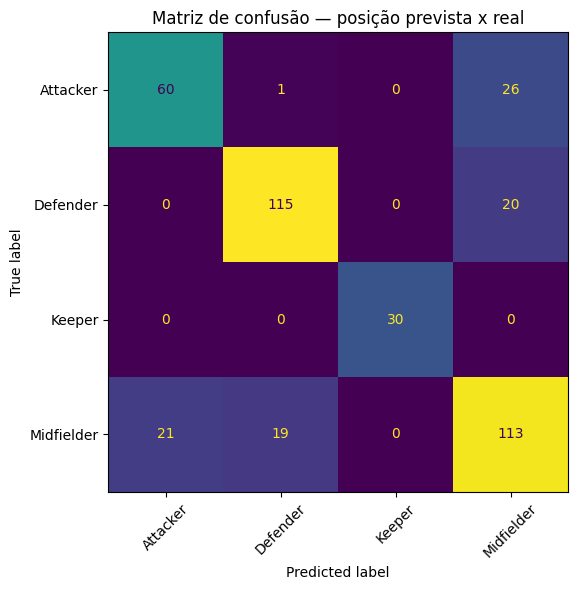

In [ ]:
posicoes = sorted(y.unique())
fig, ax = plt.subplots(figsize=(6,6))
ConfusionMatrixDisplay.from_predictions(
    y_teste, previsoes, labels=posicoes, ax=ax, colorbar=False,
    xticks_rotation=45)
plt.title("Matriz de confusão — posição prevista x real")
plt.tight_layout()
plt.show()

## 7) Quais estatísticas mais denunciam a posição? (com descrições)

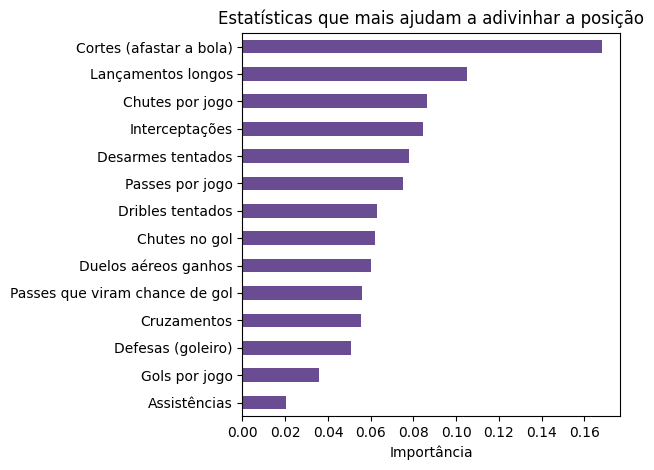

Estatística mais importante: Cortes (afastar a bola)


In [ ]:
importancias = (pd.Series(modelo.feature_importances_, index=estilo)
                  .rename(DESCRICOES)
                  .sort_values())

importancias.plot(kind="barh", color="#6a4c93")
plt.title("Estatísticas que mais ajudam a adivinhar a posição")
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

print("Estatística mais importante:", importancias.idxmax())

## 🧪 Experimente você mesmo!
1. **Sem defesas:** remova `"saves"` de `DESCRICOES`. O modelo ainda separa bem os goleiros?
2. **Só ataque:** use `estilo = ["total_shots","goals","dribbles_attempted","key_passes"]`. Quais posições ficam mais difíceis de distinguir?
3. **Quem o modelo confunde?** Olhe a matriz de confusão: meias e atacantes se misturam? Por quê?
4. **Ache um jogador:** filtre `jogadores[jogadores["name"]=="Bruno Fernandes"]`, passe suas estatísticas para `modelo.predict(...)` e veja se acerta a posição.

✍️ **Sua conclusão:**
> ...